In [1]:
PROJECT_NAME = "yolov5_train"
BASE_MODEL = "yolov5m6.pt"
TRAIN_BATCH = 32
TRAIN_EPOCHS = 200
VAL_BATCH = 64

In [2]:
! git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 12348, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 12348 (delta 4), reused 5 (delta 2), pack-reused 12335
Receiving objects: 100% (12348/12348), 12.18 MiB | 16.78 MiB/s, done.
Resolving deltas: 100% (8518/8518), done.


In [3]:
! pip install -qr yolov5/requirements.txt

In [4]:
import torch
from yolov5 import utils
import torch
from IPython import display
from IPython.display import clear_output
from pathlib import Path
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import io
import os
import cv2
import json
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

%matplotlib inline

In [5]:
IMAGES_PATH = "../input/yolov5-game-dataset-for-darknet-framework/images"
LABELS_PATH = "../input/yolov5-game-dataset-for-darknet-framework/labels"
NOTES_PATH = "../input/yolov5-game-dataset-for-darknet-framework/notes.json"

In [6]:
# Read labels
labels = os.listdir(LABELS_PATH)

# Split data
train, test = train_test_split(labels, test_size=0.15, shuffle=True)
valid, test = train_test_split(test, test_size=0.2)

print(f"train: {len(train)}; valid: {len(valid)}; test: {len(test)}")

train: 542; valid: 76; test: 20


In [7]:
os.makedirs("test/images")
os.makedirs("test/labels")
os.makedirs("train/images")
os.makedirs("train/labels")
os.makedirs("valid/images")
os.makedirs("valid/labels")

In [8]:
def move_files_to_dir(files, dirname):
    for label_filename in files:
        image_filename = f"{label_filename[:-4]}.png"
        shutil.copy(f"{IMAGES_PATH}/{image_filename}", f"{dirname}/images/{image_filename}")
        shutil.copy(f"{LABELS_PATH}/{label_filename}", f"{dirname}/labels/{label_filename}")

# Move splits to folders
move_files_to_dir(train, "train")
move_files_to_dir(test, "test")
move_files_to_dir(valid, "valid")

In [9]:
descr_darknet = json.load(open(NOTES_PATH))

train_path = "../train/images"
test_path = "../test/images"
valid_path = "../valid/images"

nc = len(descr_darknet["categories"])
names = [category["name"] for category in descr_darknet["categories"]]

print(
    f"train: {train_path}\n"
    f"test: {test_path}\n"
    f"val: {valid_path}\n\n"
    f"nc: {nc}\n"
    f"names: {names}",
)

train: ../train/images
test: ../test/images
val: ../valid/images

nc: 5
names: ['coconut', 'dandelion-empty', 'dandelion-full', 'fluff', 'palm']


In [10]:
with open("data.yaml", "w") as file:
    yaml.dump({
        "train": train_path,
        "test": test_path,
        "val": valid_path,
        "nc": nc,
        "names": [f'{name}' for name in names]
    }, stream=file, default_flow_style=None)

In [11]:
print("Now we are ready to train yolov5 model")
! ls 

Now we are ready to train yolov5 model
__notebook__.ipynb  data.yaml  test  train  valid  yolov5


In [12]:
# Delete old results if exists
wildcard = f"{PROJECT_NAME}/feature_extraction*"
! rm -r $wildcard

rm: cannot remove 'yolov5_train/feature_extraction*': No such file or directory


In [13]:
! python yolov5/train.py --batch $TRAIN_BATCH --epochs $TRAIN_EPOCHS --data "data.yaml" --weights $BASE_MODEL --project $PROJECT_NAME --name 'feature_extraction' --cache --freeze 12

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: W&B disabled due to login timeout.
train: weights=yolov5m6.pt, cfg=, data=data.yaml, hyp=yolov5/data/hyps/hyp.scratch-low.yaml, epochs=200, batch_size=32, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=yolov5_train, name=feature_extraction, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[12], save_period=-1, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v6.1-270-g6935a54 Python-3.7.12 torch-1.11.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

hyperparameters: lr0=0.01, lrf=0.01, mom

In [14]:
# Delete old results
wildcard = f"{PROJECT_NAME}/validation_on_test_data*"
! rm -r $wildcard

rm: cannot remove 'yolov5_train/validation_on_test_data*': No such file or directory


In [15]:
WEIGHTS_BEST = f"{PROJECT_NAME}/feature_extraction/weights/best.pt"
! python yolov5/val.py --weights $WEIGHTS_BEST --batch $VAL_BATCH --data 'data.yaml' --task test --project $PROJECT_NAME --name 'validation_on_test_data' --augment

val: data=data.yaml, weights=['yolov5_train/feature_extraction/weights/best.pt'], batch_size=64, imgsz=640, conf_thres=0.001, iou_thres=0.6, task=test, device=, workers=8, single_cls=False, augment=True, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=yolov5_train, name=validation_on_test_data, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v6.1-270-g6935a54 Python-3.7.12 torch-1.11.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 378 layers, 35272008 parameters, 0 gradients, 48.9 GFLOPs
test: Scanning '/kaggle/working/yolov5/../test/labels' images and labels...20 fo
test: New cache created: /kaggle/working/yolov5/../test/labels.cache
               Class     Images     Labels          P          R     mAP@.5 mAP@
                 all         20         53      0.838       0.96      0.953      0.598
             coconut         20          5      0.989          1      0.995      0.359
     dandelion-empty         20

In [16]:
# Delete old results
wildcard = f"{PROJECT_NAME}/detect_test*"
! rm -r $wildcard

rm: cannot remove 'yolov5_train/detect_test*': No such file or directory


In [17]:
! python yolov5/detect.py --weights $WEIGHTS_BEST --conf 0.6 --source 'test/images' --project $PROJECT_NAME --name 'detect_test' --augment --line=3

detect: weights=['yolov5_train/feature_extraction/weights/best.pt'], source=test/images, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.6, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=True, visualize=False, update=False, project=yolov5_train, name=detect_test, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 v6.1-270-g6935a54 Python-3.7.12 torch-1.11.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 378 layers, 35272008 parameters, 0 gradients, 48.9 GFLOPs
image 1/20 /kaggle/working/test/images/047b82e7-1656349585.png: 576x640 1 dandelion-empty, 4 fluffs, Done. (0.102s)
image 2/20 /kaggle/working/test/images/1012120f-1656435260.png: 576x640 1 dandelion-empty, 4 fluffs, Done. (0.101s)
image 3/20 /kaggle/working/test/images/17f6c477-1656349269.png: 576x640 2 dandelion-fulls, Done. (

In [18]:
def read_images(dirpath):
  images = []
  for img_filename in os.listdir(dirpath):
    images.append(mpimg.imread(f"{dirpath}/{img_filename}"))
  return images

In [19]:
def label_test_images(test_images_path, test_labels_path, classes):
  test_images = os.listdir(test_images_path)
  labeled_images = []

  for idx, test_image_filename in enumerate(test_images):
    image = mpimg.imread(f"{test_images_path}/{test_image_filename}")
    
    x_shape, y_shape = image.shape[1], image.shape[0]

    test_label_filename = f"{test_image_filename[:-4]}.txt"
    
    with open(f"{test_labels_path}/{test_label_filename}", "r") as f:
      lines = f.readlines()

      for line in lines:
        # Parse line
        box = line.split()
        class_idx = box[0]
        
        class_name = names[int(class_idx)]
        x_center, y_center, box_w, box_h = int(float(box[1])*x_shape), int(float(box[2])*y_shape), int(float(box[3])*x_shape), int(float(box[3])*y_shape)
        x1, y1, x2, y2 = x_center-int(box_w/2), y_center-int(box_h/2), x_center+int(box_w/2), y_center+int(box_h/2)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 3)
        cv2.putText(image, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 3)

    labeled_images.append(image)

  return labeled_images

In [20]:
detect_path = f"{PROJECT_NAME}/detect_test"
test_images_path = f"test/images"
test_labels_path = f"test/labels"

detected_images = read_images(detect_path)
test_labeled_images = label_test_images(test_images_path, test_labels_path, classes=names)

stacked_images = [np.hstack([detected_images[idx], test_labeled_images[idx]]) for idx in range(len(detected_images))]

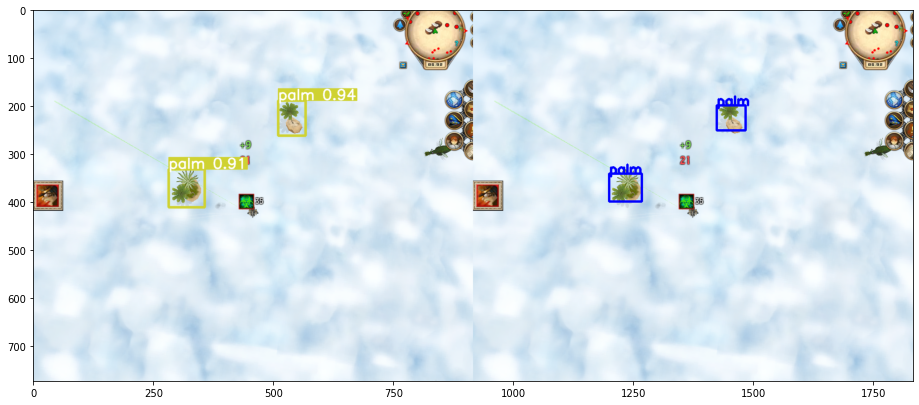

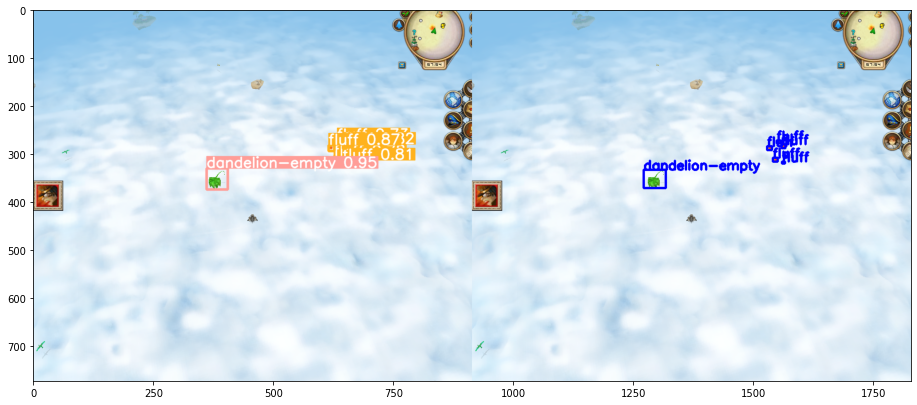

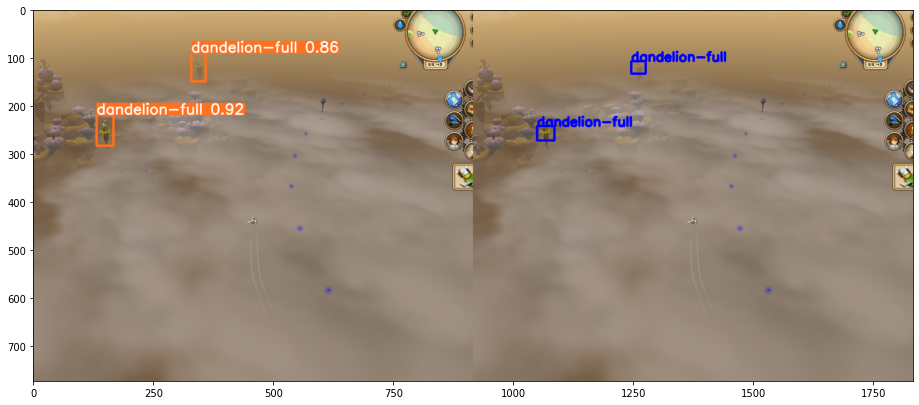

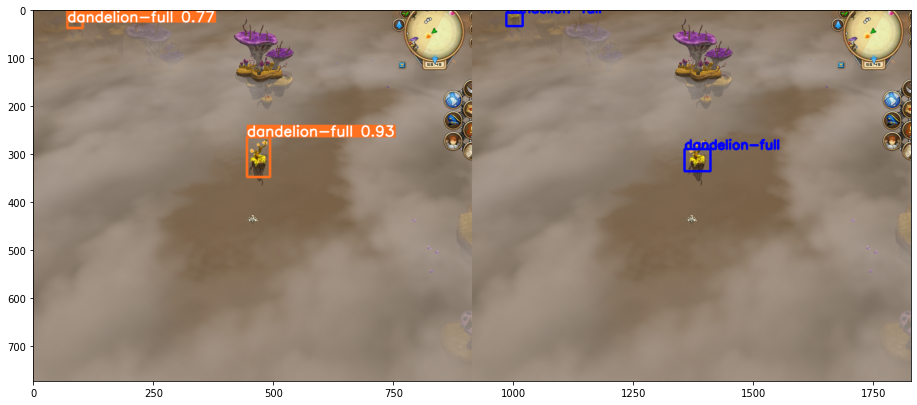

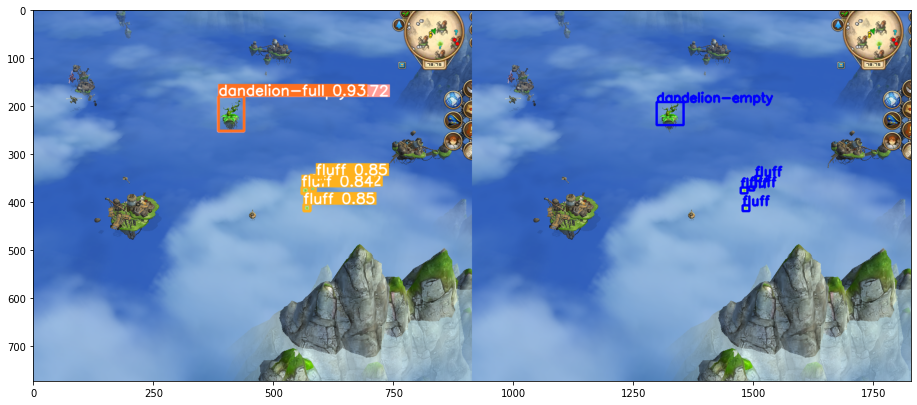

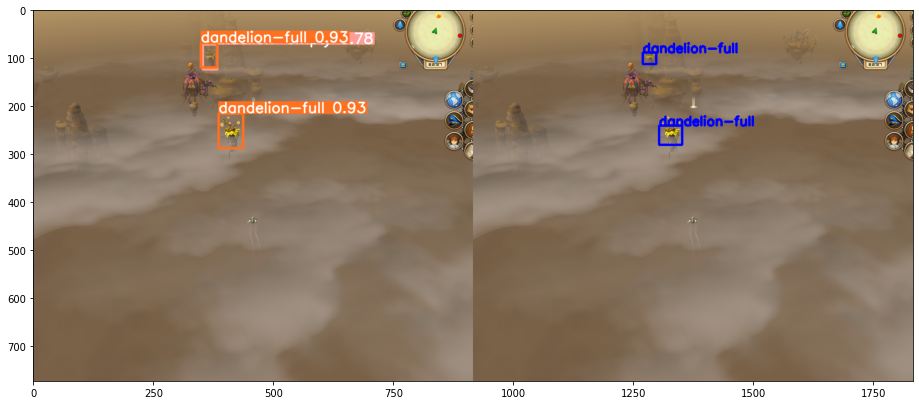

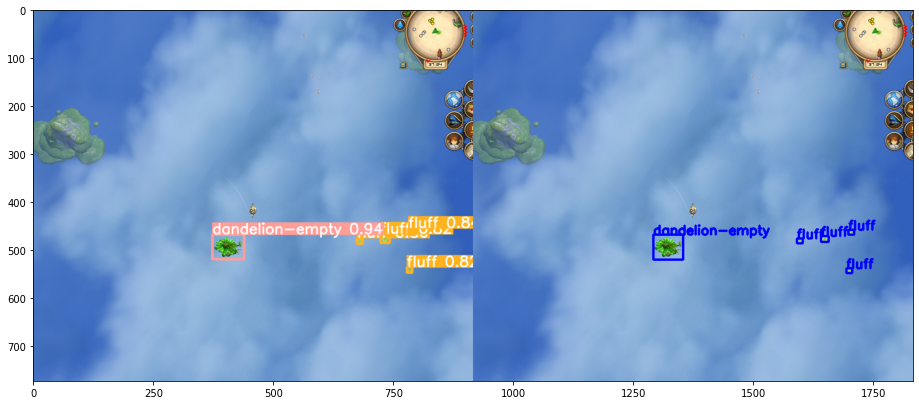

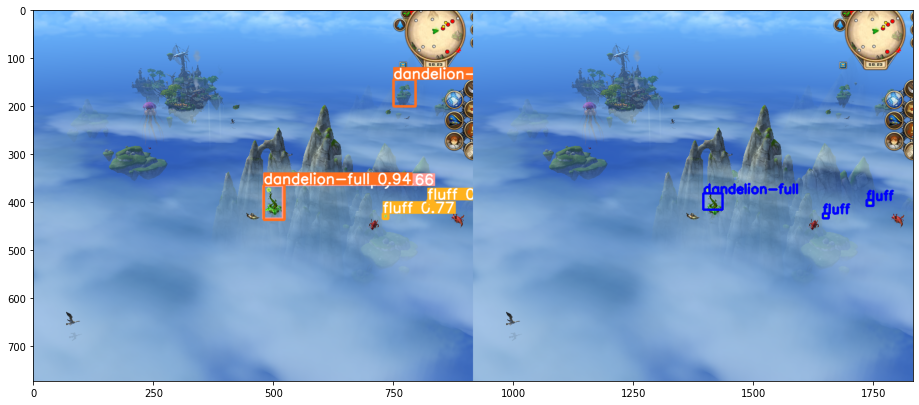

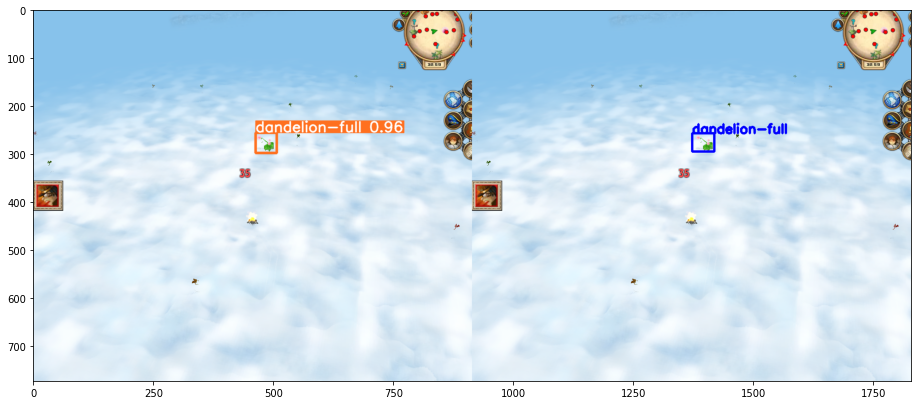

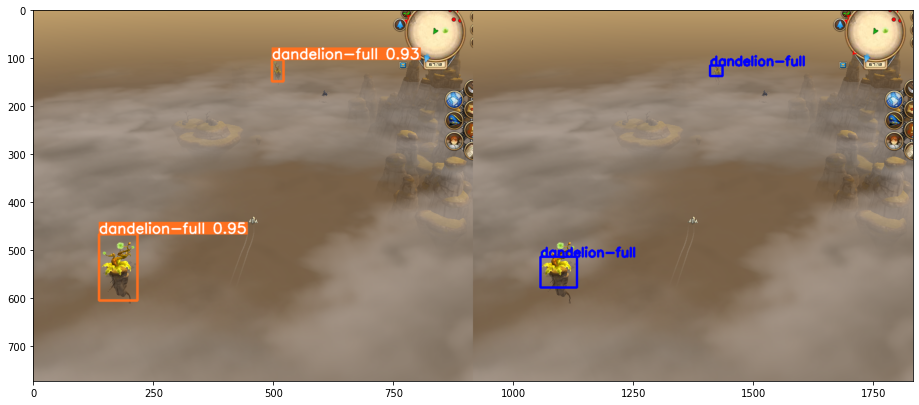

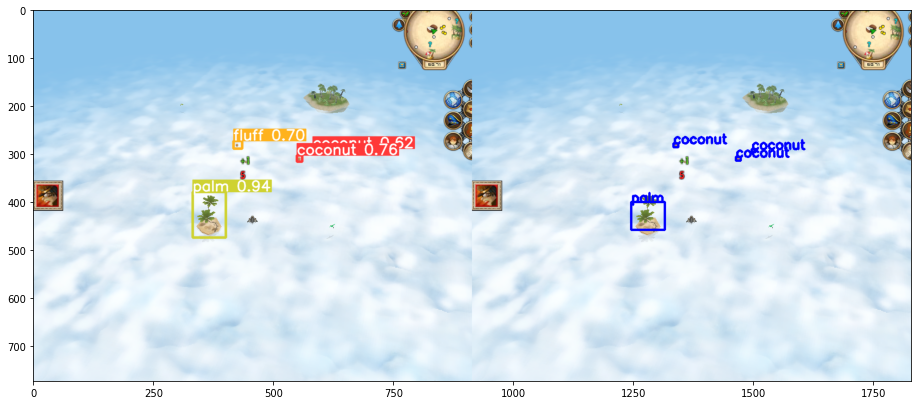

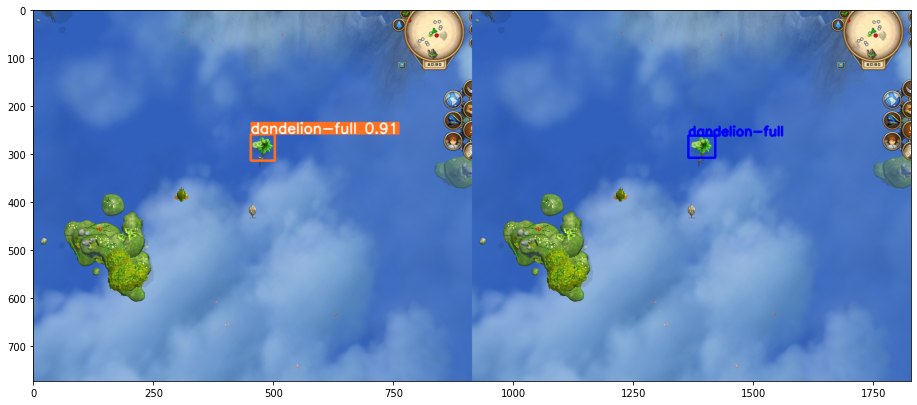

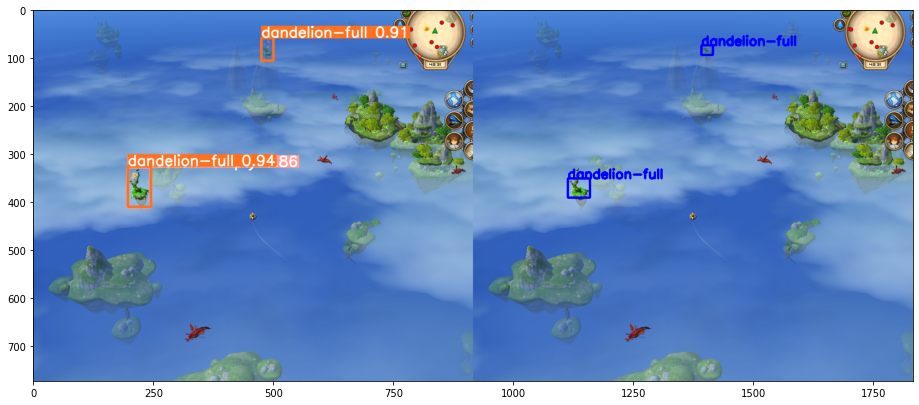

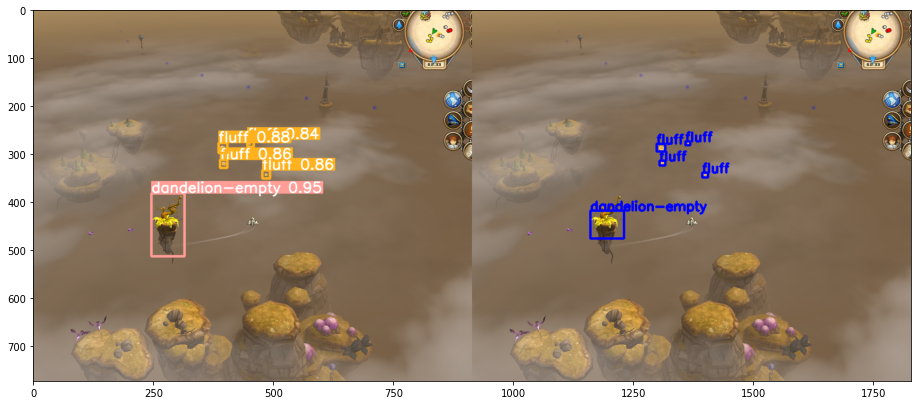

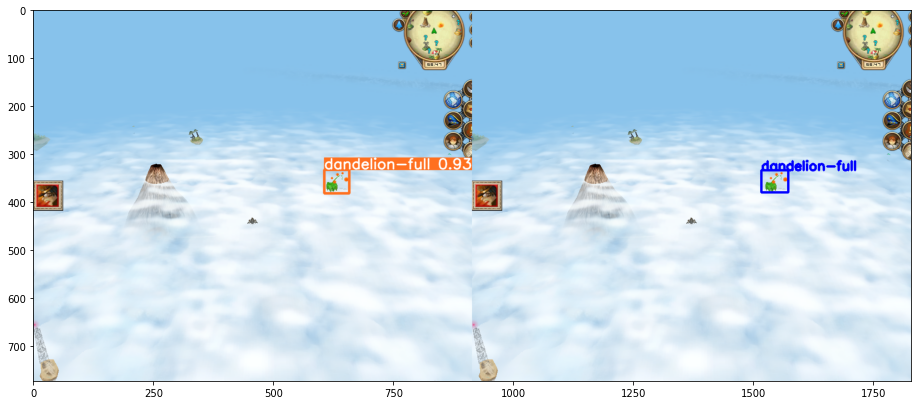

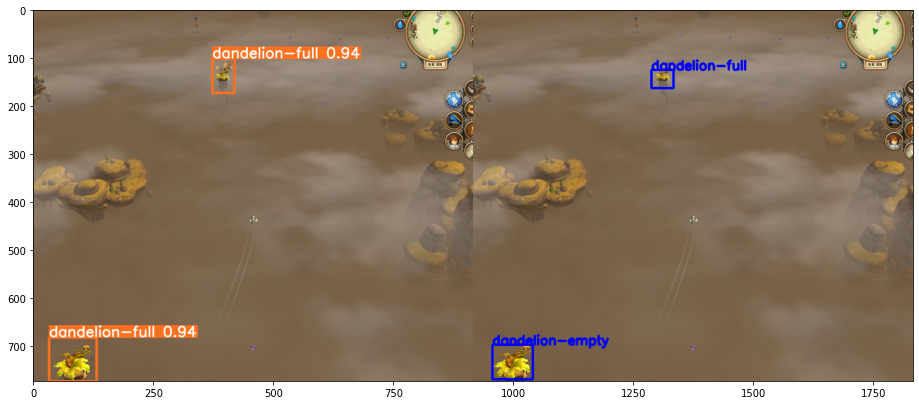

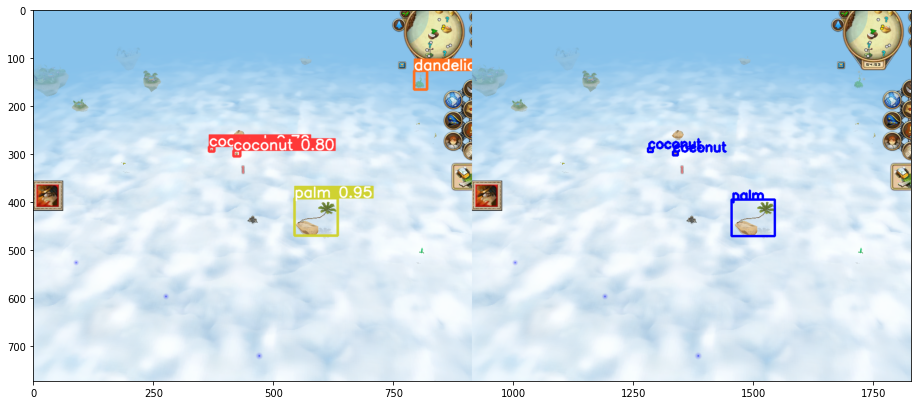

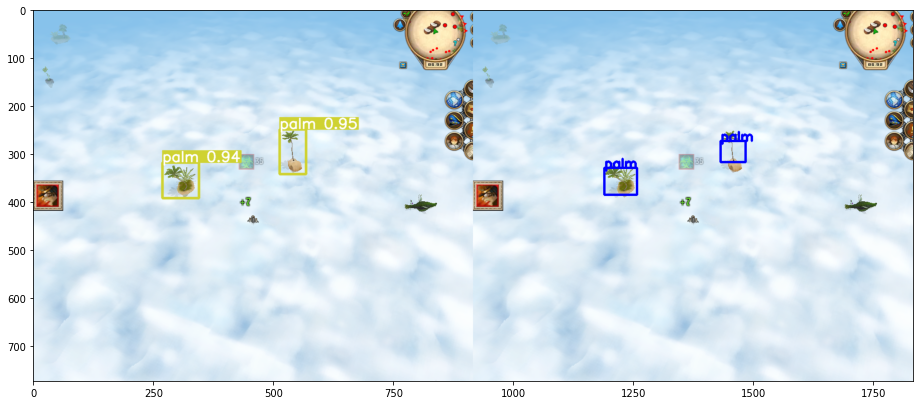

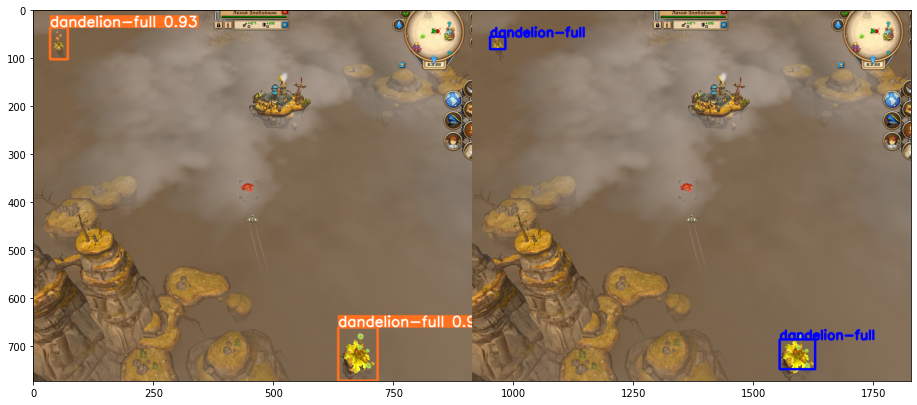

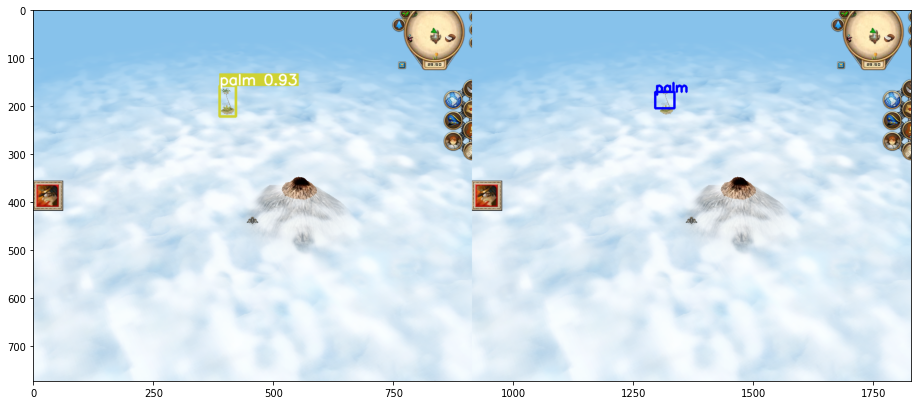

In [21]:
for image in stacked_images:
  fig = plt.figure(figsize=(40, 15))
  ax1 = fig.add_subplot(2,2,1)
  ax1.imshow(image)